In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Input, Conv2D, Concatenate, LeakyReLU, BatchNormalization, \
    Activation, Conv2DTranspose, Dropout
from keras.optimizers import Adam
from keras import Model
# from keras.image_utils import load_img,img_to_array
from keras.utils.image_utils import load_img, img_to_array
import os
from keras.initializers import RandomNormal


# def display_img(g_model):
#   try_image,try_target=get_image(1,real_images,target_images)
#   gen_image=g_model.predict(try_image)
#   try_image=(try_image+1.)/2.
#   try_target=(try_target+1.)/2.
#   gen_image=(gen_image+1.)/2.

#   fig,(ax1,ax2,ax3)= plt.subplots(1,3)
#   ax1.imshow(try_image,cmap='rgb',vmin=0,vmax=1)
#   ax2.imshow(try_target,cmap='rgb',vmin=0,vmax=1)
#   ax3.imshow(gen_image,cmap='rgb',vmin=0,vmax=1)
#   plt.show()




In [3]:
def discriminator(img_shape):
    img = Input(shape=img_shape)
    translated = Input(shape=img_shape)
    inp = Concatenate()([img, translated])
    init=RandomNormal(stddev=0.02)

    layer = Conv2D(64, kernel_size=(4, 4), strides=(2, 2), padding='same',kernel_initializer=init)(inp)
    layer = LeakyReLU(alpha=0.2)(layer)
    # 128,128,64

    layer = Conv2D(128, kernel_size=(4, 4), strides=(2, 2), padding='same',kernel_initializer=init)(layer)
    layer = BatchNormalization()(layer)
    layer = LeakyReLU(alpha=0.2)(layer)
    # 64,64,128

    layer = Conv2D(256, kernel_size=(4, 4), strides=(2, 2), padding='same',kernel_initializer=init)(layer)
    layer = BatchNormalization()(layer)
    layer = LeakyReLU(alpha=0.2)(layer)
    # 32,32,256

    layer = Conv2D(512, kernel_size=(4, 4), strides=(2, 2), padding='same',kernel_initializer=init)(layer)
    layer = BatchNormalization()(layer)
    layer = LeakyReLU(alpha=0.2)(layer)
    # 16,16,512
    
    layer = Conv2D(512, kernel_size=(4, 4), padding='same',kernel_initializer=init)(layer)
    layer = BatchNormalization()(layer)
    layer = LeakyReLU(alpha=0.2)(layer)
    # 16,16,512

    layer = Conv2D(1, kernel_size=(4, 4), padding='same',kernel_initializer=init)(layer)
    # 16,16,1
    layer = Activation('sigmoid')(layer)

    model = Model([img, translated], layer)
    optimizer = Adam(0.001, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=optimizer)
    return model

In [4]:
def encoder_block(units, prev_layer, batch_normalization=True, ):
    init=RandomNormal(stddev=0.02)
    layer = Conv2D(filters=units, kernel_size=(4, 4), strides=(2, 2), padding='same',kernel_initializer=init)(prev_layer)
    # layer = Conv2D(filters=units, kernel_size=(8,8), strides=(4,4), padding='same', kernel_initializer=init)(prev_layer)
    if batch_normalization:
        layer = BatchNormalization()(layer)
    layer = LeakyReLU(alpha=0.2)(layer)
    return layer


def decoder_block(units, inp, concat_layer, dropout=True):
    init=RandomNormal(stddev=0.02)
    layer = Conv2DTranspose(units, kernel_size=(4,4), strides=(2,2), padding='same',kernel_initializer=init)(inp)
    layer = BatchNormalization()(layer)
    # if dropout:
    #     layer=Dropout(0.5)(layer)
    layer = Concatenate()([layer, concat_layer])
    layer = Activation('relu')(layer)
    return layer


def generator(img_shape):
    img = Input(shape=img_shape)
    # 256,256,3
    layer1 = encoder_block(64, img, batch_normalization=False)
    # 128,128,64
    layer2 = encoder_block(128, layer1)
    # 64,64,128
    layer3 = encoder_block(256, layer2)
    # 32,32,256
    layer4 = encoder_block(512, layer3)
    # 16,16,512
    layer5 = encoder_block(512, layer4)
    # 8,8,512
    layer6 = encoder_block(512, layer5)
    # 4,4,512
    b = Conv2D(512, kernel_size=(4, 4), activation='relu', strides=(2, 2), padding='same')(layer6)
    # 1,1,512

    # img=Input(shape=img_shape)
    # #256,256,3
    # layer1=encoder_block(64,img,batch_normalization=False)
    # #64,64,64
    # layer2=encoder_block(128,layer1)
    # #16,16,128
    # layer3=encoder_block(256,layer2)
    # #4,4,256
    # b=Conv2D(512,kernel_size=(4,4),activation='relu')(layer3)
    # #1,1,512

    d1 = decoder_block(512, b, layer6)
    # 2,2,1024
    d2 = decoder_block(512, d1, layer5)
    # 4,4,1024
    d3 = decoder_block(512, d2, layer4)
    # 8,8,1024
    d4 = decoder_block(512, d3, layer3)
    # 16,16,1024
    d5 = decoder_block(256, d4, layer2)
    # 32,32,512
    d6 = decoder_block(128, d5, layer1)
    # 64,64,256
    d8 = Conv2DTranspose(3, kernel_size=(4, 4), strides=(2, 2), padding='same')(d6)
    # 256,256,3
    final = Activation('tanh')(d8)

    # d1=decoder_block(256,b,layer3)
    # #4,4,512
    # d2=decoder_block(128,d1,layer2)
    # #16,16,256
    # d3=decoder_block(64,d2,layer1)
    # #64,64,128
    # d4=Conv2DTranspose(3,kernel_size=(8,8),strides=(4,4),padding='same')(d3)
    # #256,256,3
    # final=Activation('tanh')(d4)

    model = Model(img, final)
    return model



In [5]:
img_shape = (256, 256, 3)
d_model = discriminator(img_shape)
g_model = generator(img_shape)


def gan(d_model, g_model, img_shape):
    d_model.trainable = False
    image = Input(shape=img_shape)
    gen_image = g_model(image)
    output = d_model([image, gen_image])

    model = Model(image, [output, gen_image])
    optimizer = Adam(0.001, beta_1=0.5)
    model.compile(loss=['binary_crossentropy', 'mae'], optimizer=optimizer, loss_weights=[1, 85])
    return model


combined = gan(d_model, g_model, img_shape)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\initializers\initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [6]:
def get_data():
    folder_path = 'maps/train/'
    real_images = []
    map_images = []
    for filename in os.listdir(folder_path):
        if filename.endswith('.jpg'):
            image_path = os.path.join(folder_path, filename)
            image = load_img(image_path, color_mode='rgb', target_size=(256, 512))
            image = img_to_array(image)
            real_img = image[:, :256]
            real_images.append(real_img)
            map_img = image[:, 256:]
            map_images.append(map_img)
    return np.array(real_images), np.array(map_images)


real_images, target_images = get_data()
real_images_test=real_images[1000:]
target_images_test=target_images[1000:]
real_images=real_images[:1000]
target_images=target_images[:1000]
real_images = (real_images - 127.5) / 127.5
target_images = (target_images - 127.5) / 127.5
real_images_test=(real_images_test-127.5)/127.5
target_images_test=(target_images_test-127.5)/127.5


def get_image(batch_size, r, t):
    x = np.random.randint(0, r.shape[0], batch_size)
    img_real = r[x]
    img_trans = t[x]
    return img_real, img_trans
    # return real_images[[0]], target_images[[0]]

In [7]:
print(real_images.shape)
print(real_images_test.shape)
print(target_images.shape)
print(target_images_test.shape)

(1000, 256, 256, 3)
(96, 256, 256, 3)
(1000, 256, 256, 3)
(96, 256, 256, 3)


In [8]:
def display_img_train(g_model,epoch):
    try_image, try_target = get_image(1, real_images, target_images)
    print(try_image.shape)
    gen_image = g_model.predict(try_image)

    # Rescale pixel values from [-1, 1] to [0, 1]
    try_image = (try_image + 1.) / 2.
    try_target = (try_target + 1.) / 2.
    gen_image = (gen_image + 1.) / 2.

    # Remove the extra dimension
    try_image = try_image.squeeze()
    try_target = try_target.squeeze()
    gen_image = gen_image.squeeze()

    # Plot the images
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    ax1.imshow(try_image)
    ax1.set_title("Input Image")
    ax1.axis('off')

    ax2.imshow(try_target)
    ax2.set_title("Target Image")
    ax2.axis('off')

    ax3.imshow(gen_image)
    ax3.set_title("Generated Image")
    ax3.axis('off')
    fig.savefig(f"image_translation_train/img{epoch}")
    # plt.show()



def display_img_test(g_model,epoch):
    try_image, try_target = get_image(1, real_images_test, target_images_test)
    print(try_image.shape)
    print(real_images_test.shape)
    gen_image = g_model.predict(try_image)

    # Rescale pixel values from [-1, 1] to [0, 1]
    try_image = (try_image + 1.) / 2.
    try_target = (try_target + 1.) / 2.
    gen_image = (gen_image + 1.) / 2.

    # Remove the extra dimension
    try_image = try_image.squeeze()
    try_target = try_target.squeeze()
    gen_image = gen_image.squeeze()

    # Plot the images
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    ax1.imshow(try_image)
    ax1.set_title("Input Image")
    ax1.axis('off')

    ax2.imshow(try_target)
    ax2.set_title("Target Image")
    ax2.axis('off')

    ax3.imshow(gen_image)
    ax3.set_title("Generated Image")
    ax3.axis('off')
    fig.savefig(f"image_translation_test/img{epoch}")
    # plt.show()

In [8]:
def train(epochs, batch_size, d_model, g_model, combined):
    start=2601
    try:
        for epoch in range(start,epochs+start):
            img_real, img_trans = get_image(int(batch_size / 2), real_images, target_images)
            print(img_real.shape)
            gen_trans = g_model.predict(img_real)
            loss_real = d_model.train_on_batch([img_real, img_trans], np.ones(shape=(img_real.shape[0], 16,16, 1)))
            loss_fake = d_model.train_on_batch([img_real, gen_trans], np.zeros(shape=(img_real.shape[0], 16,16, 1)))
            d_loss = (loss_fake + loss_real) / 2
            real, target = get_image(batch_size, real_images, target_images)
            print(real.shape)
            g_loss = combined.train_on_batch(real, [np.ones(shape=(batch_size, 16,16, 1)), target])
            print(f"epoch={epoch} : d_loss={d_loss} g_loss={g_loss}")
            if epoch % 50 == 0:
                display_img_train(g_model,epoch)
                display_img_test(g_model,epoch)

            if epoch%200==0:
                g_model.save(f'generator_translation2_{epoch}.h5')
                d_model.save(f'discriminator_translation2_{epoch}.h5')
                combined.save(f'combined_translation2_{epoch}.h5') 
    
    except Exception as e:
        print(e)
        g_model.save('generator_translation2.h5')
        d_model.save('discriminator_translation2.h5')
        combined.save('combined_translation2.h5')    

# from keras.models import load_model    
# g_model=load_model('generator_translation.h5')
# d_model=load_model('discriminator_translation.h5')
# combined=load_model('combined_translation.h5')

# optimizer = Adam(0.001, beta_1=0.5)
# d_model.compile(loss='binary_crossentropy', optimizer=optimizer)
# combined.compile(loss=['binary_crossentropy', 'mae'], optimizer=optimizer, loss_weights=[1, 100])



In [9]:
from keras.models import load_model
g_model=load_model('generator_translation2_2600.h5')
d_model=load_model('discriminator_translation2_2600.h5')
combined=load_model('combined_translation2_2600.h5')
optimizer = Adam(0.001, beta_1=0.5)
d_model.compile(loss='binary_crossentropy', optimizer=optimizer)
combined.compile(loss=['binary_crossentropy', 'mae'], optimizer=optimizer, loss_weights=[1, 110])

In [10]:
train(10001,64,d_model,g_model,combined)

(32, 256, 256, 3)
1/1 [==============================] - 26s 26s/step
(64, 256, 256, 3)
epoch=2601 : d_loss=1.5188526213169098 g_loss=[3.973170280456543, 0.2000715732574463, 0.034300897270441055]
(32, 256, 256, 3)
1/1 [==============================] - 0s 101ms/step
(64, 256, 256, 3)
epoch=2602 : d_loss=1.5145388096570969 g_loss=[6.337953567504883, 0.08482840657234192, 0.05684659257531166]
(32, 256, 256, 3)
1/1 [==============================] - 0s 180ms/step
(64, 256, 256, 3)
epoch=2603 : d_loss=1.5155868083238602 g_loss=[4.963449001312256, 0.08227503299713135, 0.04437430948019028]
(32, 256, 256, 3)
1/1 [==============================] - 0s 230ms/step
(64, 256, 256, 3)
epoch=2604 : d_loss=1.5018869787454605 g_loss=[4.818727493286133, 0.23055872321128845, 0.04171062260866165]
(32, 256, 256, 3)
1/1 [==============================] - 0s 54ms/step
(64, 256, 256, 3)
epoch=2605 : d_loss=1.5474545806646347 g_loss=[4.286290645599365, 0.1210298091173172, 0.037866007536649704]
(32, 256, 256, 3)

C:\Users\MVI_lab_2\AppData\Local\Temp\ipykernel_7272\1553801491.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))


1/1 [==============================] - 0s 16ms/step
(32, 256, 256, 3)
1/1 [==============================] - 0s 23ms/step
(64, 256, 256, 3)
epoch=3151 : d_loss=1.4873112887144089 g_loss=[3.844794273376465, 0.15178704261779785, 0.03357279300689697]
(32, 256, 256, 3)
1/1 [==============================] - 0s 30ms/step
(64, 256, 256, 3)
epoch=3152 : d_loss=1.5358262956142426 g_loss=[3.8485279083251953, 0.10697971284389496, 0.03401407599449158]
(32, 256, 256, 3)
1/1 [==============================] - 0s 25ms/step
(64, 256, 256, 3)
epoch=3153 : d_loss=1.52266526222229 g_loss=[3.7148735523223877, 0.17679616808891296, 0.03216433897614479]
(32, 256, 256, 3)
1/1 [==============================] - 0s 19ms/step
(64, 256, 256, 3)
epoch=3154 : d_loss=1.516449123620987 g_loss=[3.8152105808258057, 0.10186955332756042, 0.03375764563679695]
(32, 256, 256, 3)
1/1 [==============================] - 0s 24ms/step
(64, 256, 256, 3)
epoch=3155 : d_loss=1.4916059523820877 g_loss=[3.560189723968506, 0.11262456

KeyboardInterrupt: 

In [9]:
from keras.models import load_model
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim,peak_signal_noise_ratio as psnr, mean_squared_error as mse 
from skimage.color import rgb2gray

g_model=load_model('generator_translation2_7000.h5')
d_model=load_model('discriminator_translation2_7000.h5')
combined=load_model('combined_translation2_7000.h5')


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\initializers\initializers.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [ ]:
#real_images_test, target_images_test
import lpips
def calculate_metric(data,t):
    loss_fn=lpips.LPIPS(net='vgg')
    ssi=[]
    psn=[]
    ms=[]
    lp=[]

    gray_ssim=[]
    gray_psnr=[]
    gray_mse=[]
    gray_lp=[]
    for i in range(data.shape[0]):
        print(i)
        img_test=np.reshape(data[i],(1,256,256,3))
        gen_img=g_model.predict(img_test)
        target=t[i]

        gen_img=(gen_img+1.)/2.
        target=(target+1.)/2.
        gen_img=gen_img.squeeze()
        target=target.squeeze()

        # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        # ax1.imshow(gen_img)
        # ax1.set_title("generated Image")
        # ax1.axis('off')

        # ax2.imshow(target)
        # ax2.set_title("Target Image")
        # ax2.axis('off')

        # fig.show()
        ssi.append(ssim(gen_img,target,channel_axis=-1,data_range=1.0))
        psn.append(psnr(gen_img,target,data_range=1.0))
        ms.append(mse(gen_img,target))
        lp.append(loss_fn(gen_img,target))

        gen_image_gray=rgb2gray(gen_img)
        target_gray=rgb2gray(target)

        gray_ssim.append(ssim(gen_image_gray,target_gray,data_range=1.0))
        gray_psnr.append(psnr(gen_image_gray,target_gray,data_range=1.0))
        gray_mse.append(mse(gen_image_gray,target_gray))
        gray_lp.append(loss_fn(gen_image_gray,target_gray))

    return ssi,psn,ms,lp,gray_ssim,gray_psnr,gray_mse,gray_lp


In [ ]:
def print_metric_rgb(ssi,psn,ms):
    #for test data in rgb
    ssi=np.array(ssi)
    psn=np.array(psn)
    ms=np.array(ms)
    lp=np.array(lp)

    #average
    print(f'SSIM (average) = {np.average(ssi)}')
    print(f'PSNR (average) = {np.average(psn)}')
    print(f'MSE (average) = {np.average(ms)}')
    print(f'Perceptual Distance (average)={np.average(lp)}')

    #best
    print(f'SSIM (max) = {np.max(ssi)}')
    print(f'PSNR (max) = {np.max(psn)}')
    print(f'MSE (min) = {np.min(ms)}')
    print(f'Perceptual Distance(min)='{np.min(lp)})

    #worst
    print(f'SSIM (min) = {np.min(ssi)}')
    print(f'PSNR (min) = {np.min(psn)}')
    print(f'MSE (max) = {np.max(ms)}')
    print(f'Perceptual Distance (max)=' {np.max(lp)})


In [12]:
def print_metric_gray(gray_ssim,gray_psnr,gray_mse):#for test data in grayscale
    gray_ssim = np.array(gray_ssim)
    gray_psnr = np.array(gray_psnr)
    gray_mse = np.array(gray_mse)

    # Print average values
    print(f'SSIM (gray, average) = {np.average(gray_ssim)}')
    print(f'PSNR (gray, average) = {np.average(gray_psnr)}')
    print(f'MSE (gray, average) = {np.average(gray_mse)}')

    # best
    print(f'SSIM (gray, max) = {np.max(gray_ssim)}')
    print(f'PSNR (gray, max) = {np.max(gray_psnr)}')
    print(f'MSE (gray, min) = {np.min(gray_mse)}')

    # worst
    print(f'SSIM (gray, min) = {np.min(gray_ssim)}')
    print(f'PSNR (gray, min) = {np.min(gray_psnr)}')
    print(f'MSE (gray, max) = {np.max(gray_mse)}')


In [13]:
#on training data
ssi,psn,ms,gray_ssim,gray_psnr,gray_mse=calculate_metric(real_images,target_images)
print_metric_rgb(ssi,psn,ms)
print()
print()
print_metric_gray(gray_ssim,gray_psnr,gray_mse)


0
1/1 [==============================] - 3s 3s/step
1
1/1 [==============================] - 0s 370ms/step
2
1/1 [==============================] - 1s 507ms/step
3
1/1 [==============================] - 0s 236ms/step
4
1/1 [==============================] - 0s 269ms/step
5
1/1 [==============================] - 0s 329ms/step
6
1/1 [==============================] - 0s 336ms/step
7
1/1 [==============================] - 0s 314ms/step
8
1/1 [==============================] - 0s 300ms/step
9
1/1 [==============================] - 0s 320ms/step
10
1/1 [==============================] - 0s 359ms/step
11
1/1 [==============================] - 0s 359ms/step
12
1/1 [==============================] - 0s 329ms/step
13
1/1 [==============================] - 0s 392ms/step
14
1/1 [==============================] - 0s 377ms/step
15
1/1 [==============================] - 0s 392ms/step
16
1/1 [==============================] - 0s 238ms/step
17
1/1 [==============================] - 0s 322ms/step
18
1/

In [14]:
#on test data
ssi,psn,ms,gray_ssim,gray_psnr,gray_mse=calculate_metric(real_images_test,target_images_test)
print_metric_rgb(ssi,psn,ms)
print()
print()
print_metric_gray(gray_ssim,gray_psnr,gray_mse)

0
1/1 [==============================] - 0s 443ms/step

Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)

1
1/1 [==============================] - 0s 413ms/step
2
1/1 [==============================] - 0s 413ms/step
3
1/1 [==============================] - 0s 372ms/step
4
1/1 [==============================] - 1s 508ms/step
5
1/1 [==============================] - 0s 433ms/step
6
1/1 [==============================] - 0s 418ms/step
7
1/1 [==============================] - 0s 416ms/step
8
1/1 [==============================] - 0s 397ms/step
9
1/1 [==============================] - 0s 415ms/step
10
1/1 [==============================] - 0s 429ms/step
11
1/1 [==============================] - 0s 416ms/step

In [21]:
!pip install scikit-image

     ---------------------------------------- 12.8/12.8 MB 3.1 MB/s eta 0:00:00
     -------------------------------------- 315.4/315.4 kB 4.8 MB/s eta 0:00:00
     -------------------------------------- 228.2/228.2 kB 6.8 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
!pip install lpips

     -------------------------------------- 53.8/53.8 kB 690.8 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


(1, 256, 256, 3)
(96, 256, 256, 3)
1/1 [==============================] - 0s 278ms/step


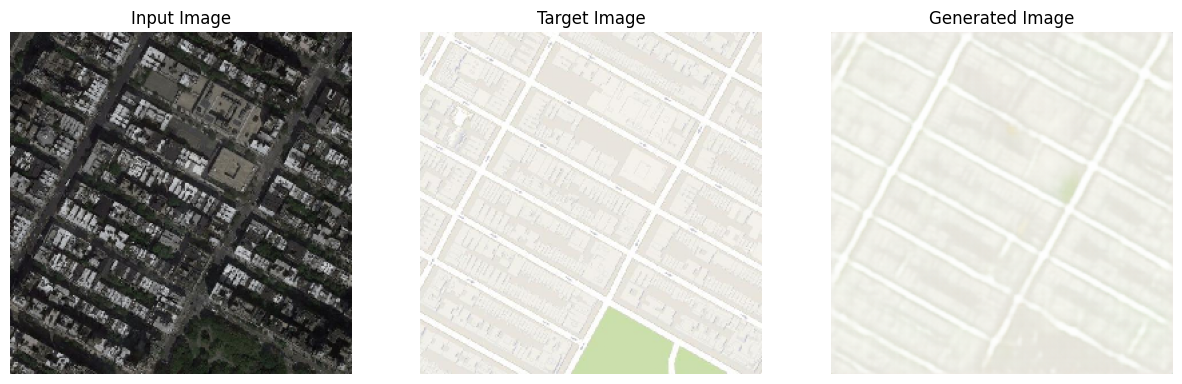

In [15]:
display_img_test(g_model,10000000)